In [22]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette("husl")

warnings.filterwarnings('ignore')


# Airbnb vs Traditional Hotels: A Comparative Analysis

## Project Overview
This analysis compares two major accommodation platforms to identify specific pricing strategies, 
booking behaviors, and market positioning differences.

## Data Sources
1. **Hotel Booking Demand Dataset**
   - Source: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
   
2. **Airbnb Open Data**
   - Source: https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata


In [4]:
print("="*70)
print("LOADING DATASET 1: HOTEL BOOKINGS")
print("="*70)

df_hotel = pd.read_csv('data/hotel_bookings.csv')

print(f"\nDataset Shape: {df_hotel.shape}")
print(f"Rows: {df_hotel.shape[0]:,}")
print(f"Columns: {df_hotel.shape[1]}")

print(f"\nColumn Names:")
for i, col in enumerate(df_hotel.columns, 1):
    print(f"{i}. {col}")

print("\n" + "="*70)

LOADING DATASET 1: HOTEL BOOKINGS

Dataset Shape: (119390, 32)
Rows: 119,390
Columns: 32

Column Names:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date



In [6]:
print("="*70)
print("LOADING DATASET 2: AIRBNB LISTINGS")
print("="*70)

df_airbnb = pd.read_csv('data/airbnb__data.csv')

print(f"\nDataset Shape: {df_airbnb.shape}")
print(f"Rows: {df_airbnb.shape[0]:,}")
print(f"Columns: {df_airbnb.shape[1]}")

print(f"\nColumn Names:")
for i, col in enumerate(df_airbnb.columns, 1):
    print(f"{i}. {col}")

print("\n" + "="*70)

LOADING DATASET 2: AIRBNB LISTINGS

Dataset Shape: (102599, 26)
Rows: 102,599
Columns: 26

Column Names:
1. id
2. NAME
3. host id
4. host_identity_verified
5. host name
6. neighbourhood group
7. neighbourhood
8. lat
9. long
10. country
11. country code
12. instant_bookable
13. cancellation_policy
14. room type
15. Construction year
16. price
17. service fee
18. minimum nights
19. number of reviews
20. last review
21. reviews per month
22. review rate number
23. calculated host listings count
24. availability 365
25. house_rules
26. license



In [7]:
print("="*70)
print("MISSING VALUES ANALYSIS - HOTELS")
print("="*70)

missing_hotel = df_hotel.isnull().sum()
missing_pct = (missing_hotel / len(df_hotel) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing_hotel.index,
    'Missing_Count': missing_hotel.values,
    'Percentage': missing_pct.values
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    print("\nColumns with missing values:\n")
    print(missing_df.to_string(index=False))
else:
    print("\nNo missing values detected!")

MISSING VALUES ANALYSIS - HOTELS

Columns with missing values:

  Column  Missing_Count  Percentage
 company         112593       94.31
   agent          16340       13.69
 country            488        0.41
children              4        0.00


In [32]:
print("="*70)
print("MISSING VALUES ANALYSIS - AIRBNB")
print("="*70)

missing_airbnb = df_airbnb.isnull().sum()
missing_pct_ab = (missing_airbnb / len(df_airbnb) * 100).round(2)

missing_df_ab = pd.DataFrame({
    'Column': missing_airbnb.index,
    'Missing_Count': missing_airbnb.values,
    'Percentage': missing_pct_ab.values
})

missing_df_ab = missing_df_ab[missing_df_ab['Missing_Count'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df_ab) > 0:
    print("\nTop 20 Columns with missing values:\n")
    print(missing_df_ab.head(20).to_string(index=False))
else:
    print("\nNo missing values detected!")

MISSING VALUES ANALYSIS - AIRBNB

Top 20 Columns with missing values:

                        Column  Missing_Count  Percentage
                   last review          15867       15.50
             reviews per month          15852       15.49
            country_normalized            527        0.51
                       country            527        0.51
              availability 365            448        0.44
                minimum nights            409        0.40
                     host name            401        0.39
            review rate number            326        0.32
calculated host listings count            319        0.31
        host_identity_verified            285        0.28
                          NAME            247        0.24
                   service fee            239        0.23
             Construction year            210        0.21
             number of reviews            183        0.18
                  country code            126        0.12
 

In [33]:
# Understanding Data Structure for Fair Comparison
print("="*70)
print("DATASET STRUCTURE ANALYSIS")
print("="*70)

print("\nHOTEL DATASET KEY COLUMNS:")
hotel_cols = df_hotel.columns.tolist()
print(f"Total columns: {len(hotel_cols)}")
print("\nRelevant columns for analysis:")
for col in hotel_cols:
    if any(keyword in col.lower() for keyword in ['country', 'adr', 'price', 'rate', 'guest', 'night', 'market', 'customer']):
        print(f"  - {col}")

print("\n" + "-"*70)

print("\nAIRBNB DATASET KEY COLUMNS:")
airbnb_cols = df_airbnb.columns.tolist()
print(f"Total columns: {len(airbnb_cols)}")
print("\nRelevant columns for analysis:")
for col in airbnb_cols[:20]:  # Show first 20 to avoid clutter
    print(f"  - {col}")

print("\n" + "="*70)

DATASET STRUCTURE ANALYSIS

HOTEL DATASET KEY COLUMNS:
Total columns: 32

Relevant columns for analysis:
  - stays_in_weekend_nights
  - stays_in_week_nights
  - country
  - market_segment
  - is_repeated_guest
  - customer_type
  - adr
  - country_normalized

----------------------------------------------------------------------

AIRBNB DATASET KEY COLUMNS:
Total columns: 25

Relevant columns for analysis:
  - id
  - NAME
  - host id
  - host_identity_verified
  - host name
  - neighbourhood group
  - neighbourhood
  - lat
  - long
  - country
  - country code
  - instant_bookable
  - cancellation_policy
  - room type
  - Construction year
  - price
  - service fee
  - minimum nights
  - number of reviews
  - last review



In [18]:
# Find Common Geographic Locations
print("="*70)
print("GEOGRAPHIC ALIGNMENT ANALYSIS")
print("="*70)

# Check Hotel countries
if 'country' in df_hotel.columns:
    print("\nHOTEL DATASET - Top Countries:")
    hotel_countries = df_hotel['country'].value_counts().head(10)
    for country, count in hotel_countries.items():
        print(f"  {country}: {count:,} bookings")

# Check Airbnb locations
location_cols = ['country', 'Country', 'country_code', 'country code']
airbnb_country_col = None
for col in location_cols:
    if col in df_airbnb.columns:
        airbnb_country_col = col
        break

if airbnb_country_col:
    print(f"\nAIRBNB DATASET - Top Countries (column: '{airbnb_country_col}'):")
    airbnb_countries = df_airbnb[airbnb_country_col].value_counts().head(10)
    for country, count in airbnb_countries.items():
        print(f"  {country}: {count:,} listings")

# Find common countries (normalize variations like USA/US)
print("\n" + "-"*70)
print("\nFINDING COMMON LOCATIONS...")

# Country mapping dictionary
country_mapping = {
    'USA': ['USA', 'US', 'United States', 'United States of America'],
    'UK': ['UK', 'GB', 'GBR', 'United Kingdom', 'Great Britain'],
    'PRT': ['PRT', 'PT', 'Portugal'],
    'ESP': ['ESP', 'ES', 'Spain'],
    'FRA': ['FRA', 'FR', 'France'],
    'ITA': ['ITA', 'IT', 'Italy'],
    'DEU': ['DEU', 'DE', 'Germany'],
}

# Normalize hotel countries
if 'country' in df_hotel.columns:
    df_hotel['country_normalized'] = df_hotel['country']
    for standard, variations in country_mapping.items():
        df_hotel.loc[df_hotel['country'].isin(variations), 'country_normalized'] = standard

# Normalize airbnb countries
if airbnb_country_col:
    df_airbnb['country_normalized'] = df_airbnb[airbnb_country_col]
    for standard, variations in country_mapping.items():
        df_airbnb.loc[df_airbnb[airbnb_country_col].isin(variations), 'country_normalized'] = standard

# Find overlap
if 'country_normalized' in df_hotel.columns and 'country_normalized' in df_airbnb.columns:
    hotel_countries_norm = set(df_hotel['country_normalized'].dropna().unique())
    airbnb_countries_norm = set(df_airbnb['country_normalized'].dropna().unique())
    common_countries = hotel_countries_norm.intersection(airbnb_countries_norm)
    
    print(f"\nCommon countries found: {len(common_countries)}")
    for country in common_countries:
        hotel_count = (df_hotel['country_normalized'] == country).sum()
        airbnb_count = (df_airbnb['country_normalized'] == country).sum()
        print(f"  {country}: {hotel_count:,} hotel bookings | {airbnb_count:,} Airbnb listings")

GEOGRAPHIC ALIGNMENT ANALYSIS

HOTEL DATASET - Top Countries:
  PRT: 47,040 bookings
  GBR: 12,055 bookings
  FRA: 10,360 bookings
  ESP: 8,489 bookings
  DEU: 7,246 bookings
  ITA: 3,749 bookings
  IRL: 3,369 bookings
  BEL: 2,334 bookings
  BRA: 2,211 bookings
  NLD: 2,100 bookings

AIRBNB DATASET - Top Countries (column: 'country'):
  United States: 101,825 listings

----------------------------------------------------------------------

FINDING COMMON LOCATIONS...

Common countries found: 1
  USA: 2,086 hotel bookings | 101,825 Airbnb listings


In [34]:
# Find Rating Columns
print("="*70)
print("RATING COLUMN IDENTIFICATION")
print("="*70)

# Hotel ratings
hotel_rating_cols = [col for col in df_hotel.columns if any(keyword in col.lower() for keyword in ['rating', 'review', 'score', 'satisfaction'])]
print(f"\nHOTEL DATASET - Potential rating columns:")
for col in hotel_rating_cols:
    print(f"  - {col}: {df_hotel[col].dtype}, non-null: {df_hotel[col].notna().sum():,}")

# Airbnb ratings
airbnb_rating_cols = [col for col in df_airbnb.columns if any(keyword in col.lower() for keyword in ['rating', 'review', 'score', 'satisfaction'])]
print(f"\nAIRBNB DATASET - Potential rating columns:")
for col in airbnb_rating_cols[:10]:  # Limit output
    print(f"  - {col}: {df_airbnb[col].dtype}, non-null: {df_airbnb[col].notna().sum():,}")

# Select best rating columns
hotel_rating = None
if hotel_rating_cols:
    # Prefer columns with most non-null values
    hotel_rating = max(hotel_rating_cols, key=lambda x: df_hotel[x].notna().sum())
    print(f"\nSelected HOTEL rating column: '{hotel_rating}'")

airbnb_rating = None
rating_options = ['review_scores_rating', 'review scores rating', 'rating', 'Rating']
for col in rating_options:
    if col in df_airbnb.columns:
        airbnb_rating = col
        print(f"Selected AIRBNB rating column: '{col}'")
        break

if not airbnb_rating and airbnb_rating_cols:
    airbnb_rating = max(airbnb_rating_cols, key=lambda x: df_airbnb[x].notna().sum())
    print(f"Selected AIRBNB rating column: '{airbnb_rating}'")

RATING COLUMN IDENTIFICATION

HOTEL DATASET - Potential rating columns:

AIRBNB DATASET - Potential rating columns:
  - number of reviews: float64, non-null: 102,169
  - last review: object, non-null: 86,485
  - reviews per month: float64, non-null: 86,500
  - review rate number: float64, non-null: 102,026
Selected AIRBNB rating column: 'number of reviews'


AIRBNB PRICE ANALYSIS

Analyzing: 'price'

Price Statistics:
  Mean: $625.29
  Median: $624.00
  Std Dev: $331.67
  Min: $50.00
  Max: $1200.00

Price Distribution:
  10th percentile: $165.00
  25th percentile: $340.00
  50th percentile: $624.00
  75th percentile: $913.00
  90th percentile: $1085.00


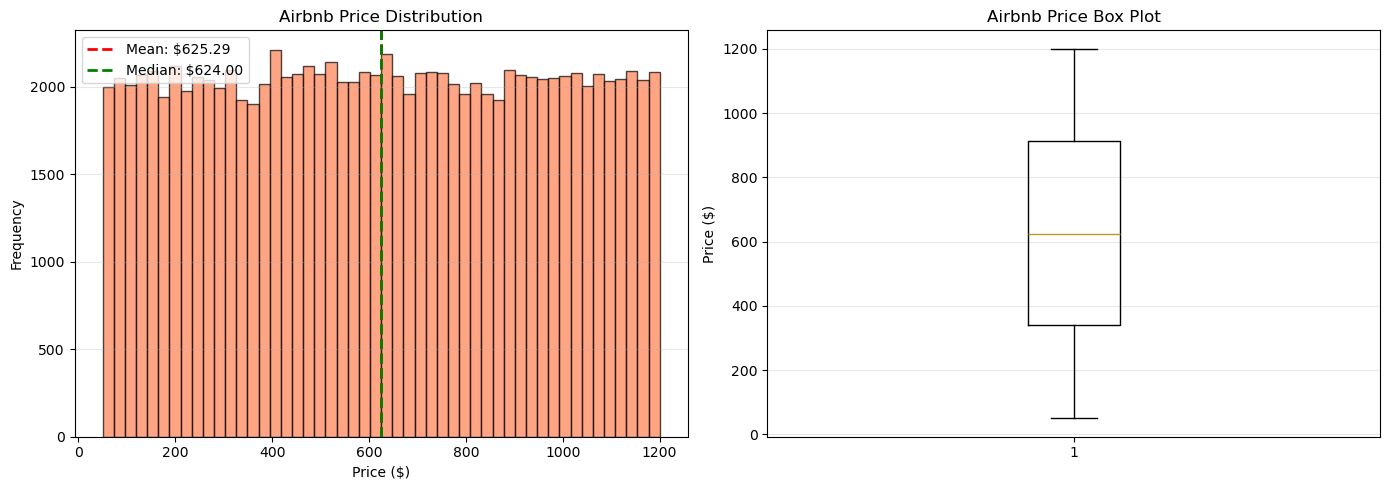


Price Segments:
  Budget (<$75): 2,146 (2.1%)
  Mid-range ($75-$150): 6,713 (6.6%)
  Premium ($150-$300): 13,230 (12.9%)
  Luxury ($300+): 80,263 (78.4%)

KEY INSIGHT:
The Luxury segment dominates with 78.4% of listings


In [23]:
# Airbnb Price Analysis (Standalone)
print("="*70)
print("AIRBNB PRICE ANALYSIS")
print("="*70)

# Find price column
airbnb_price = None
for col in df_airbnb.columns:
    if 'price' in col.lower():
        airbnb_price = col
        break

if airbnb_price:
    print(f"\nAnalyzing: '{airbnb_price}'")
    
    # Basic statistics
    print(f"\nPrice Statistics:")
    print(f"  Mean: ${df_airbnb[airbnb_price].mean():.2f}")
    print(f"  Median: ${df_airbnb[airbnb_price].median():.2f}")
    print(f"  Std Dev: ${df_airbnb[airbnb_price].std():.2f}")
    print(f"  Min: ${df_airbnb[airbnb_price].min():.2f}")
    print(f"  Max: ${df_airbnb[airbnb_price].max():.2f}")
    
    # Price distribution by percentiles
    print(f"\nPrice Distribution:")
    for percentile in [10, 25, 50, 75, 90]:
        value = df_airbnb[airbnb_price].quantile(percentile/100)
        print(f"  {percentile}th percentile: ${value:.2f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df_airbnb[airbnb_price], bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[0].axvline(df_airbnb[airbnb_price].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df_airbnb[airbnb_price].mean():.2f}')
    axes[0].axvline(df_airbnb[airbnb_price].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df_airbnb[airbnb_price].median():.2f}')
    axes[0].set_xlabel('Price ($)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Airbnb Price Distribution')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Box plot
    axes[1].boxplot(df_airbnb[airbnb_price], vert=True)
    axes[1].set_ylabel('Price ($)')
    axes[1].set_title('Airbnb Price Box Plot')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Price segments
    budget = (df_airbnb[airbnb_price] < 75).sum()
    mid = ((df_airbnb[airbnb_price] >= 75) & (df_airbnb[airbnb_price] < 150)).sum()
    premium = ((df_airbnb[airbnb_price] >= 150) & (df_airbnb[airbnb_price] < 300)).sum()
    luxury = (df_airbnb[airbnb_price] >= 300).sum()
    
    print(f"\nPrice Segments:")
    print(f"  Budget (<$75): {budget:,} ({budget/len(df_airbnb)*100:.1f}%)")
    print(f"  Mid-range ($75-$150): {mid:,} ({mid/len(df_airbnb)*100:.1f}%)")
    print(f"  Premium ($150-$300): {premium:,} ({premium/len(df_airbnb)*100:.1f}%)")
    print(f"  Luxury ($300+): {luxury:,} ({luxury/len(df_airbnb)*100:.1f}%)")
    
    print(f"\nKEY INSIGHT:")
    dominant_segment = max([('Budget', budget), ('Mid-range', mid), ('Premium', premium), ('Luxury', luxury)], key=lambda x: x[1])
    print(f"The {dominant_segment[0]} segment dominates with {dominant_segment[1]/len(df_airbnb)*100:.1f}% of listings")